In [22]:
import os
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [23]:
with open("analytics.json", "r") as f:
    d = eval(f.read())

In [24]:
Counter([len(i) for i in d['participants'][33:]])

Counter({14: 84, 12: 33, 15: 1658})

In [25]:
df = pd.read_csv("Cleaned_study_data.csv")
df

,StartDate_post,EndDate_post,Status_post,IPAddress_post,Progress_post,Duration (in seconds)_post,Finished_post,RecordedDate_post,ResponseId_post,RecipientLastName_post,...,ih_dwell_p,mc_correct,n_op,n_comments,zip_state_match,speeder,commented,posted,passcode,gold_star
0,12/12/2023 10:34,12/12/2023 10:37,IP Address,71.71.112.54,100,217,True,12/12/2023 10:37,R_2ARnUkZ40c702IE,NaN,...,0.220734,1,1,2,1,0,1,1,True,0
1,12/12/2023 10:46,12/12/2023 10:52,IP Address,172.58.10.215,100,374,True,12/12/2023 10:52,R_27amtKO2JE7Iho9,NaN,...,0.109973,1,1,1,1,1,1,1,True,1
2,12/12/2023 10:47,12/12/2023 10:56,IP Address,66.212.218.70,100,520,True,12/12/2023 10:56,R_2Cy58sTvdtprJbm,NaN,...,0.141557,1,1,1,1,1,1,1,True,1
3,12/12/2023 10:55,12/12/2023 11:00,IP Address,68.116.85.163,100,260,True,12/12/2023 11:00,R_3QXJjMxRbpGVqnN,NaN,...,0.036418,1,1,1,1,1,1,1,True,1
4,12/12/2023 10:52,12/12/2023 11:06,IP Address,174.215.176.210,100,885,True,12/12/2023 11:06,R_2YLnKFzaVR8F7Mj,NaN,...,0.181847,1,1,1,1,1,1,1,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,12/12/2023 11:18,12/12/2023 11:25,IP Address,73.3.224.41,93,434,False,12/15/2023 0:33,R_1ddeajwrFRZrG73,NaN,...,0.092647,1,1,5,1,1,1,1,True,1
1039,12/12/2023 11:59,12/12/2023 12:02,IP Address,100.40.186.229,93,189,False,12/15/2023 0:33,R_27fMb9wZPSEktas,NaN,...,0.342752,1,0,4,1,1,0,1,True,0
1040,12/12/2023 11:32,12/12/2023 11:35,IP Address,172.56.15.42,93,197,False,12/15/2023 0:33,R_2ZKzyLxSf1s9NeJ,NaN,...,0.209302,1,1,1,1,1,1,1,True,1
1041,12/13/2023 13:25,12/13/2023 13:29,IP Address,24.99.26.176,93,222,False,12/15/2023 0:33,R_15KKEVD99jKy9Di,NaN,...,0.000000,1,1,5,1,1,1,1,True,1


In [26]:
ids = set(df.participant_code)

In [27]:
d = [i for i in d['participants'] if len(i) == 15]
d = [i for i in d if i['participantCode'].lower() in ids]
len(d)

1043

In [28]:
post_info = pd.read_csv("participant_content.csv")
post_info = post_info[pd.isnull(post_info.parentPost)]
post_info = post_info[post_info.staticContent == 1]
post_info = post_info[['postOrCommentId','postOrCommentText']].drop_duplicates()
post_info

,postOrCommentId,postOrCommentText
0,654e2ecbf18dbd001f7aadfc,I'm honestly curious about what the other side...
6,654e2ecbf18dbd001f7aae16,I understand the argument that the system need...
11,654e2ecbf18dbd001f7aae22,The bottom line is that we benefit from the hu...
12,654e2ecbf18dbd001f7aae48,A wall is an expensive an useless symbolic end...
13,654e2ecbf18dbd001f7aaebe,Illegal immigrants do pay taxes. There is a ta...
...,...,...
1737,655d0ae8f1c1b5001f5cb3bd,There should be gun bans even though gun enthu...
1743,655d0ae8f1c1b5001f5cb3bf,A good guy with a gun can kill a bad guy with ...
1748,655d0ae8f1c1b5001f5cb3c1,Automatic rifles need to be illegal.
1755,655d0ae8f1c1b5001f5cb3d1,"If gun control means gun ban, then yes. Though..."


In [29]:
count = 0

txt_n = {}
txt_ids = {}
n_ids = {}
ids_n = {}

for ind, row in post_info.iterrows():
    txt = row.postOrCommentText
    ids = row.postOrCommentId
    if txt not in txt_n:
        txt_n[txt] = count
        txt_ids[txt] = []
        n_ids[count] = []
        count += 1
    txt_ids[txt].append(ids)
    n_ids[txt_n[txt]].append(ids)
    ids_n[ids] = txt_n[txt]

In [30]:
frmt = '%Y-%m-%dT%H:%M:%S'

count_all = 0
count_valid = 0
over_count = 0
overs = []
descriptions = set()
n_analytics = []
user_post_dwells = set()
dwells = defaultdict(dict)

for i in d:
    over = False
    end_time = datetime.strptime(i['exitSurveySchedule'].split('.')[0], frmt)
    end_time += timedelta(seconds=10)
    n_analytics.append(len(i['analytics']))
    for a in i['analytics']:
        descriptions.add(a['meta']['description'])
        if a['meta']['description'] == "User dwell time on post":
            count_all += 1
            t = datetime.strptime(a['meta']['timestamp'].split('.')[0], frmt)
            if  t <= end_time:
                count_valid += 1
                if a['meta']['postId'] in ids_n:
                    post = ids_n[a['meta']['postId']]
                    user_post_dwells.add((i['participantCode'],post))
                    if post not in dwells[i['participantCode']]:
                        dwells[i['participantCode']][post] = 0.0
                    dwells[i['participantCode']][post] += a['meta']['dwellTimeInSeconds']
            else:
                over = True
                overs.append((t - end_time).seconds)
                
    if over:
        over_count += 1

print(descriptions)
print(count_all)
print(count_valid)
print(over_count)
print(np.mean(n_analytics))

{'User marked notification as unread', 'User marked notification as read', 'User time writing post', 'User opened notification', 'User liked post', 'User disliked post', 'User time writing comment', 'User opened comment thread', 'User removed dislike from post', 'User viewed comment', 'User dwell time on post', 'User removed like from post'}
183230
181675
183
270.744966442953


In [31]:
183/1043

0.17545541706615533

In [32]:
(183230 - 181675)/2183 

0.7123224919835089

In [33]:
len([i for i in overs if i < 600])/len(overs)

0.9704180064308682

(array([ 2.,  0.,  2.,  0.,  1.,  3., 17.,  9., 24., 51.]),
 array([11. , 15.8, 20.6, 25.4, 30.2, 35. , 39.8, 44.6, 49.4, 54.2, 59. ]),
 <BarContainer object of 10 artists>)

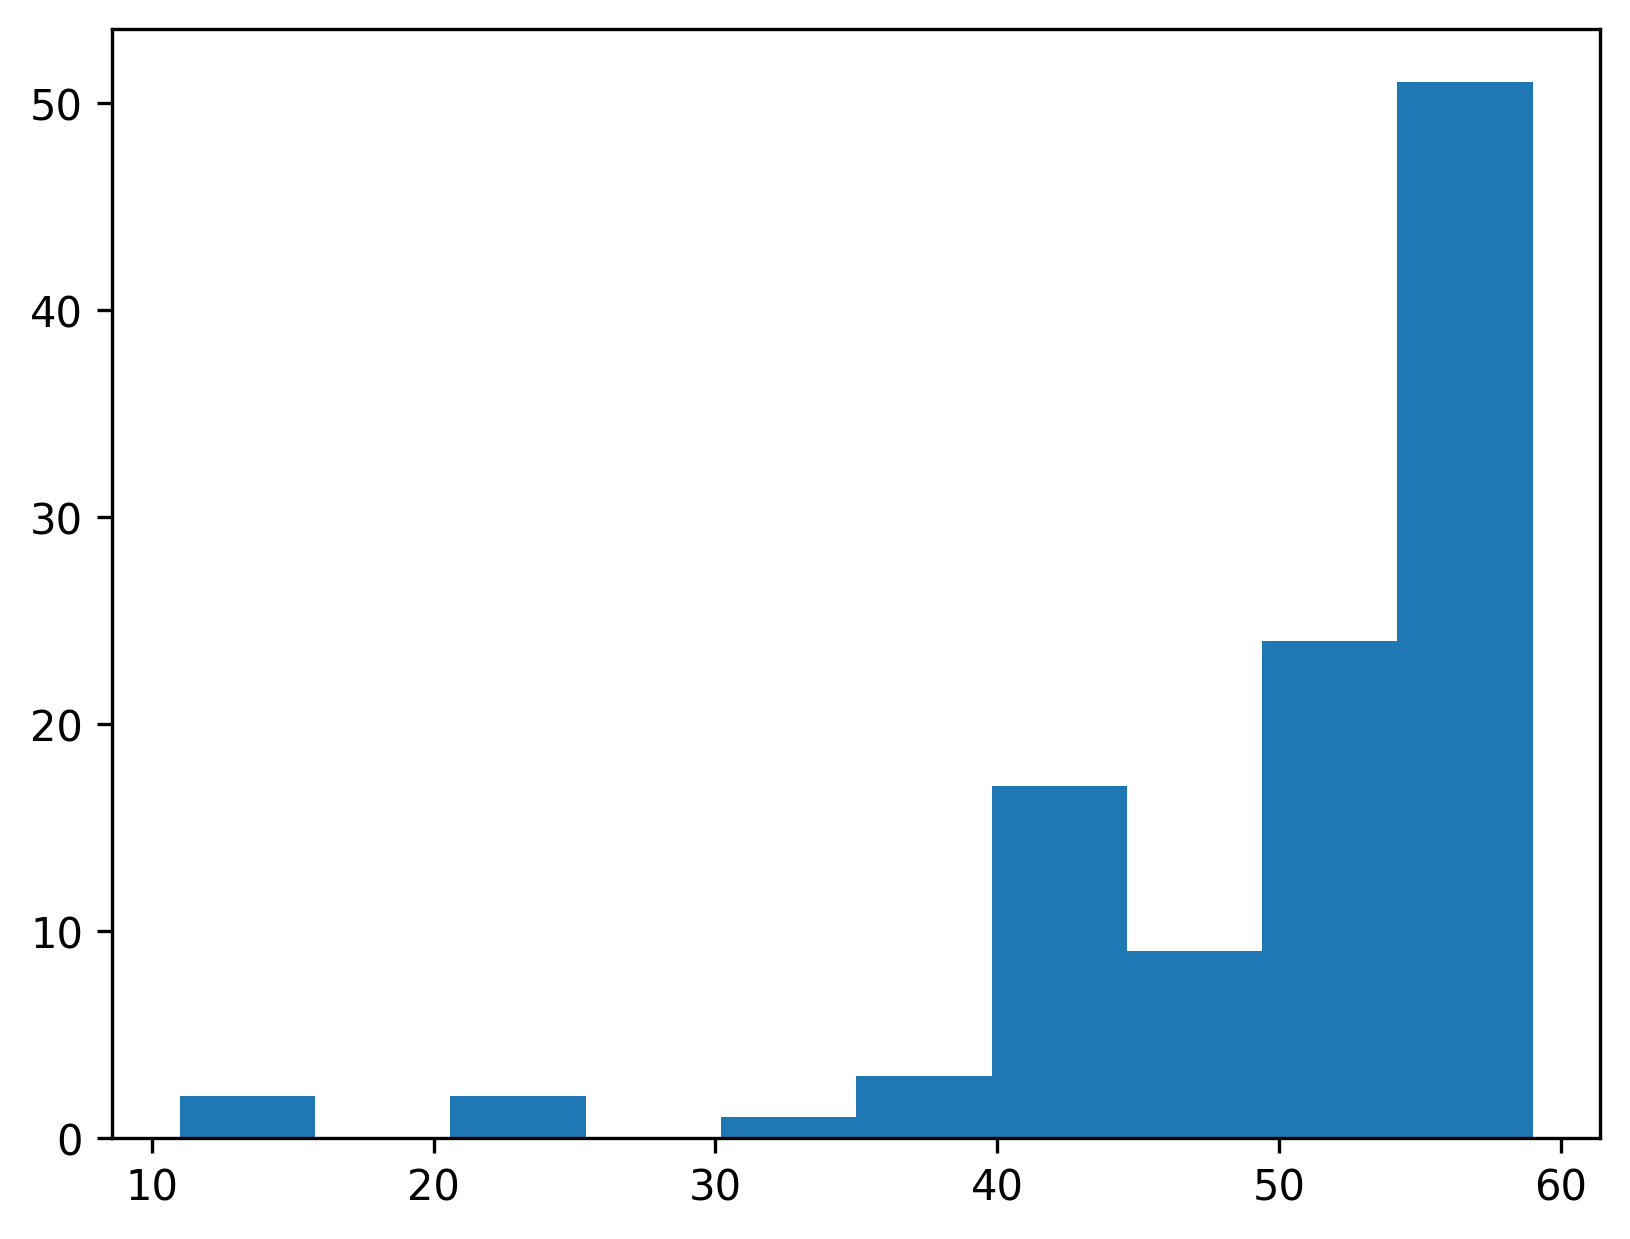

In [34]:
plt.figure(dpi=300)
plt.hist([i for i in overs if i < 60])

In [35]:
post_counts = sorted(Counter([i[1] for i in user_post_dwells]).items(), key=lambda x: x[1], reverse=True)
post_counts

[(36, 989),
 (21, 460),
 (2, 456),
 (57, 442),
 (45, 437),
 (73, 434),
 (52, 429),
 (71, 429),
 (48, 429),
 (15, 425),
 (38, 422),
 (5, 421),
 (32, 419),
 (17, 417),
 (49, 410),
 (74, 394),
 (65, 389),
 (4, 388),
 (22, 383),
 (46, 380),
 (29, 378),
 (66, 365),
 (30, 358),
 (47, 357),
 (35, 351),
 (27, 351),
 (58, 337),
 (11, 336),
 (20, 333),
 (13, 331),
 (26, 330),
 (70, 326),
 (40, 319),
 (67, 316),
 (1, 316),
 (0, 315),
 (14, 306),
 (61, 306),
 (60, 305),
 (34, 305),
 (62, 305),
 (12, 298),
 (54, 295),
 (43, 294),
 (68, 294),
 (3, 290),
 (18, 290),
 (28, 285),
 (76, 284),
 (24, 282),
 (9, 282),
 (56, 275),
 (33, 274),
 (69, 267),
 (25, 265),
 (63, 264),
 (19, 261),
 (55, 260),
 (75, 260),
 (37, 254),
 (8, 253),
 (6, 252),
 (51, 247),
 (16, 243),
 (39, 236),
 (23, 233),
 (44, 227),
 (72, 225),
 (10, 224),
 (42, 221),
 (53, 220),
 (50, 214),
 (31, 210),
 (7, 208),
 (41, 202),
 (64, 197),
 (59, 181)]

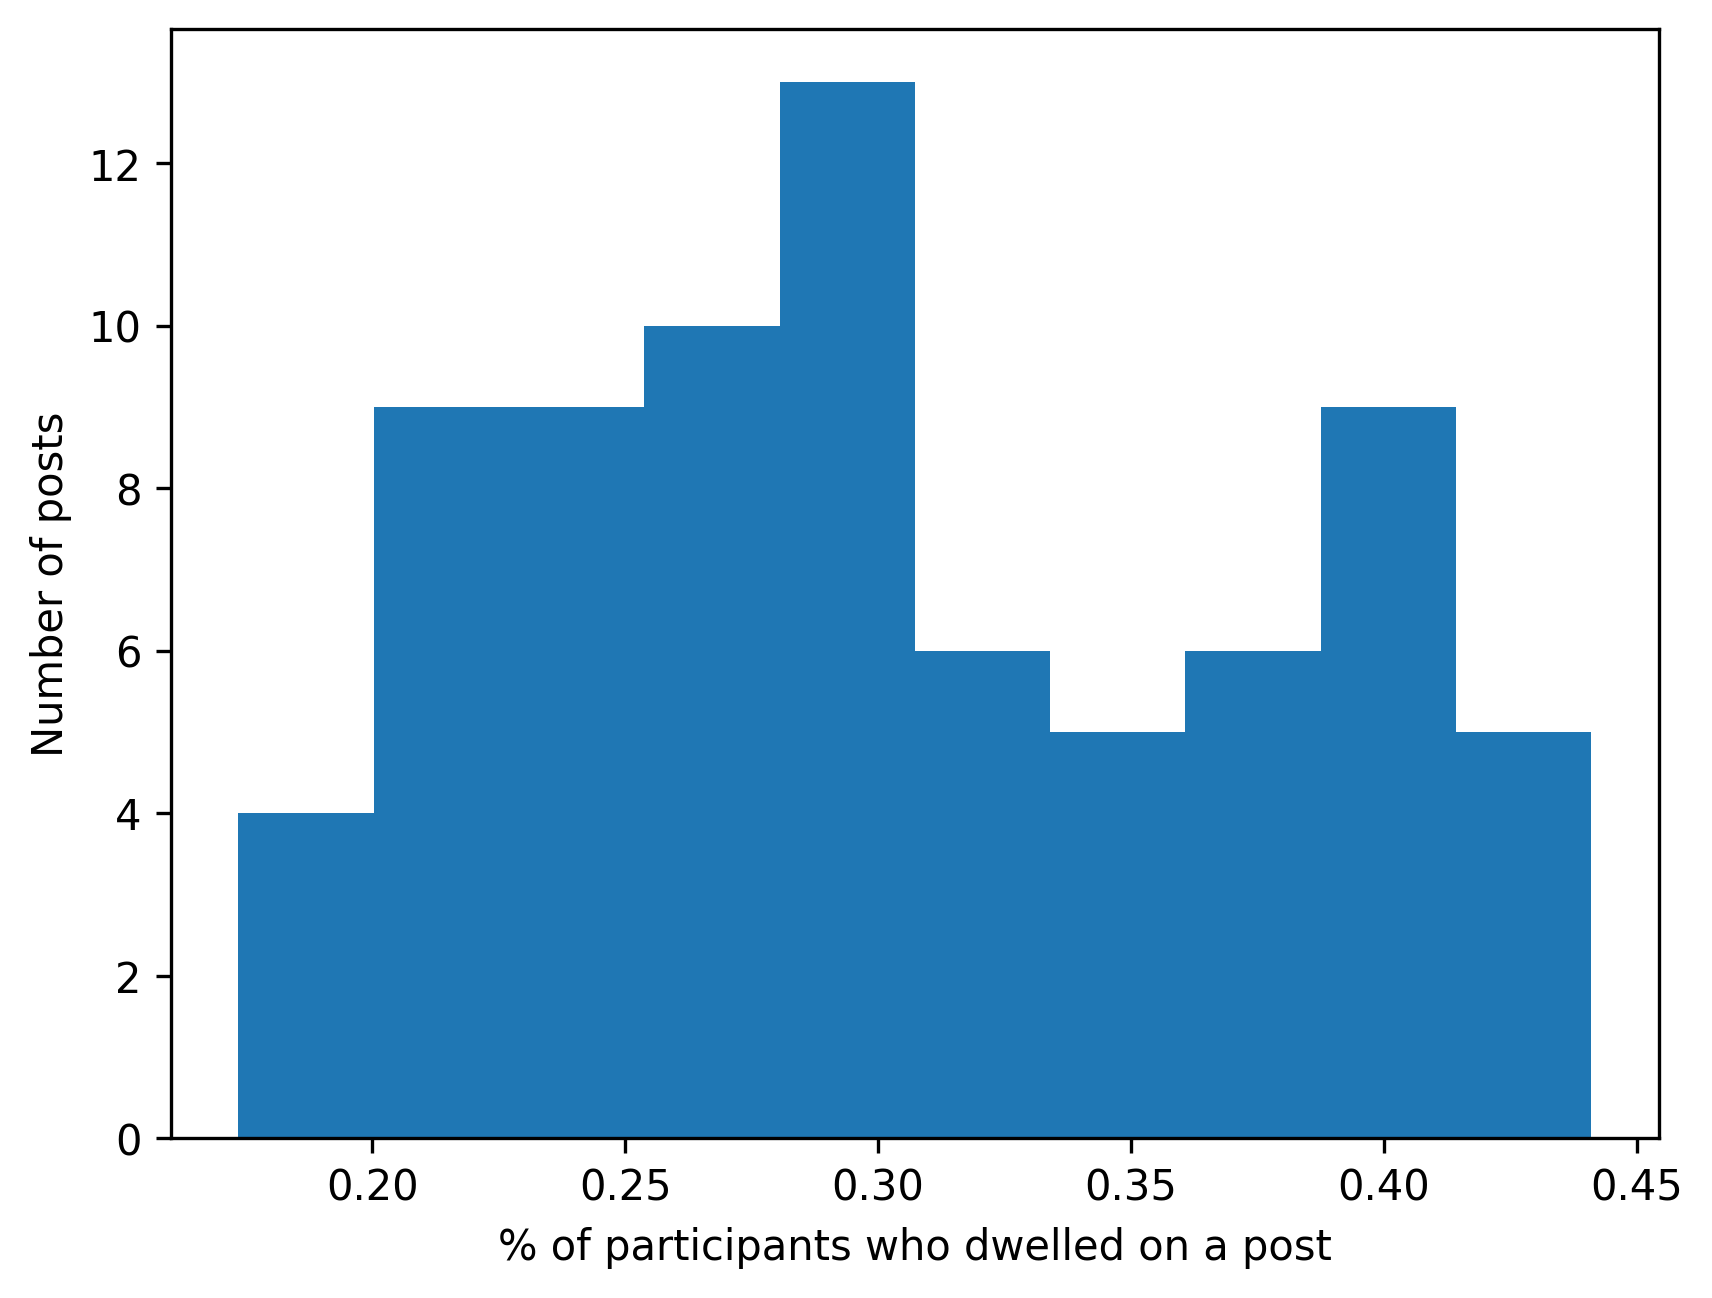

In [36]:
x = [i[1]/1043 for i in post_counts if i[1] < 989]
plt.figure(dpi=300)
plt.xlabel("% of participants who dwelled on a post")
plt.ylabel("Number of posts")
plt.hist(x, bins=10)
plt.show()

In [37]:
total_dwells = defaultdict(float)

for i in dwells:
    for j in dwells[i]:
        total_dwells[j] += dwells[i][j]
        
x = [(i[1]*2)/1043 for i in total_dwells.items() if i[0] != 36]

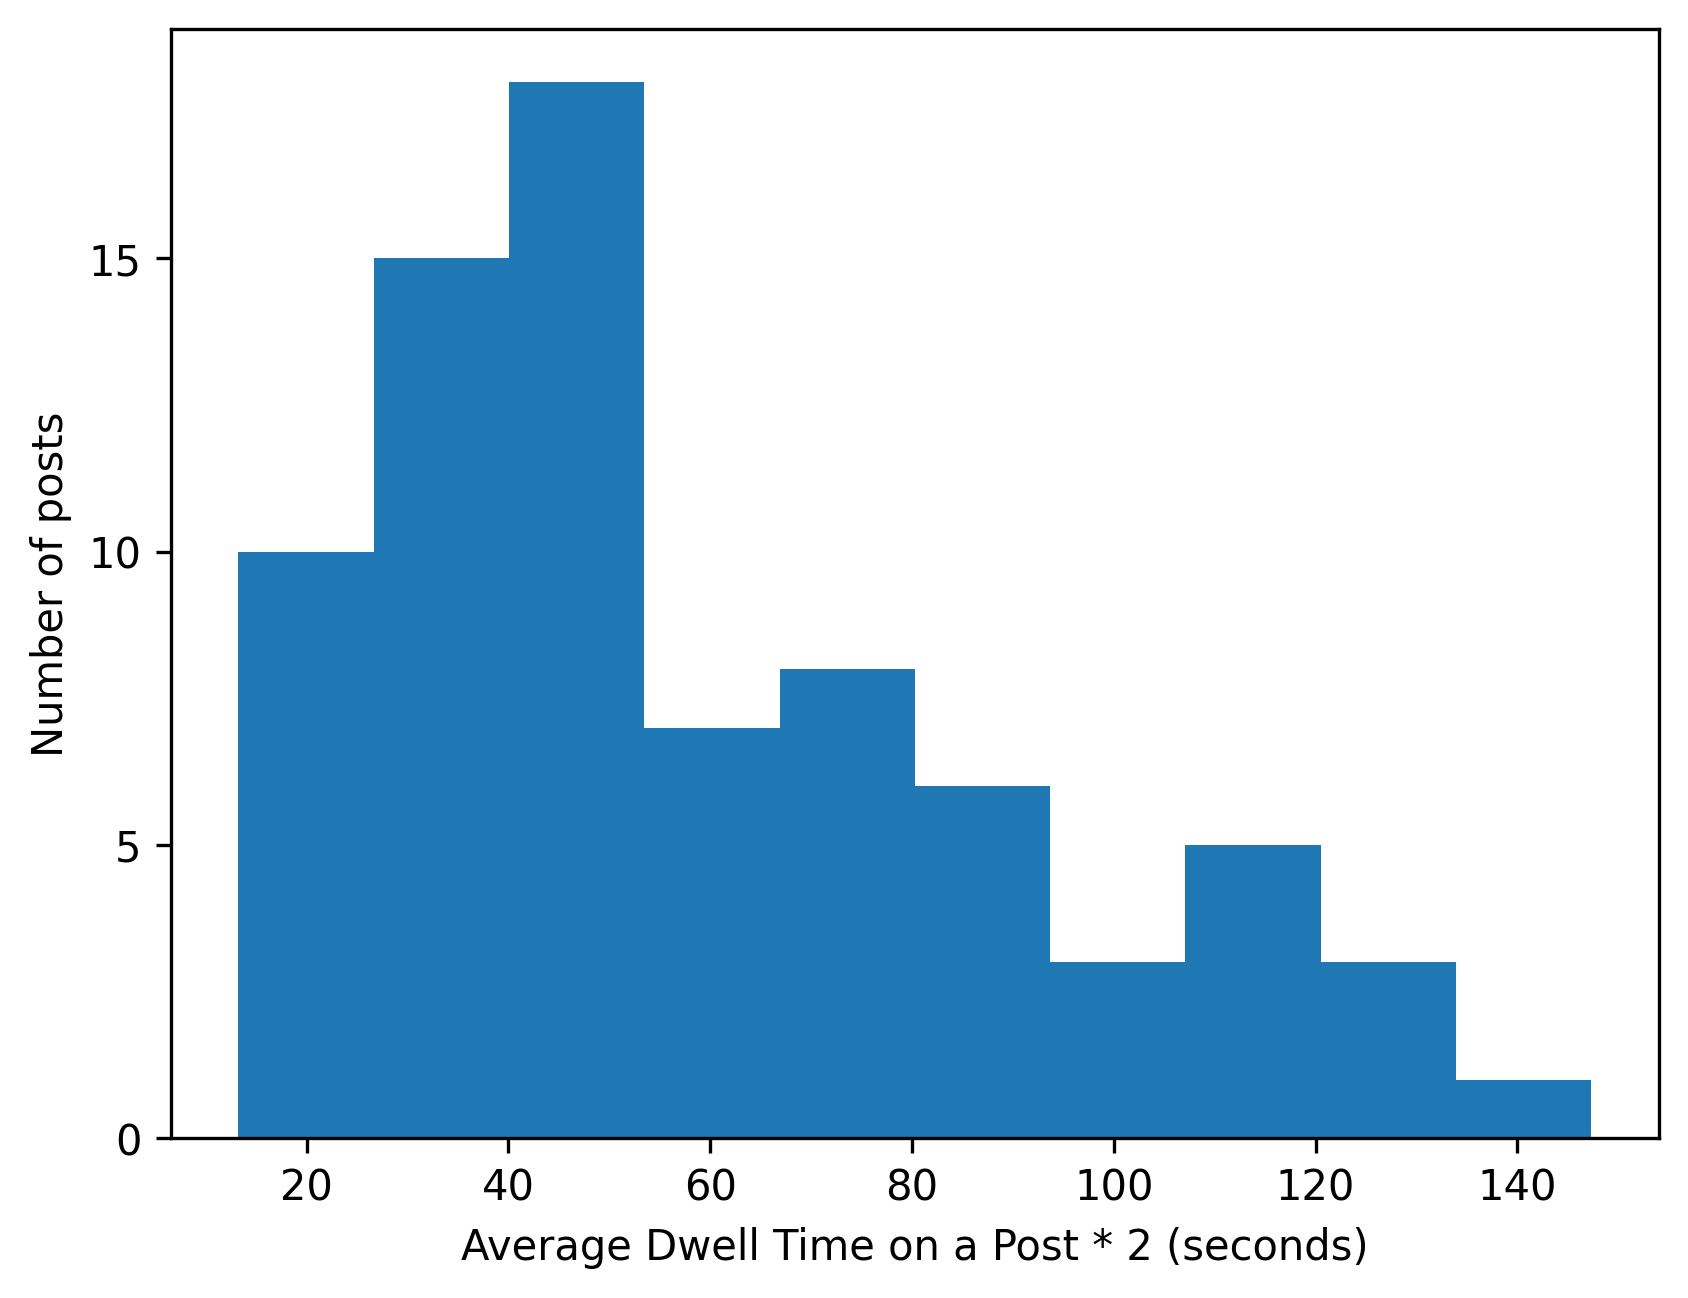

In [38]:
plt.figure(dpi=300)
plt.xlabel("Average Dwell Time on a Post * 2 (seconds)")
plt.ylabel("Number of posts")
plt.hist(x, bins=10)
plt.yticks([0,5,10,15])
plt.show()

In [39]:
min(x)

13.238734419942473

In [40]:
sorted(total_dwells.items(), key=lambda x: x[1], reverse=True)

[(36, 141400.0),
 (2, 76827.0),
 (21, 68410.0),
 (4, 67609.0),
 (65, 63913.0),
 (45, 61554.0),
 (38, 59497.0),
 (15, 59372.0),
 (57, 57735.0),
 (71, 56919.0),
 (46, 55373.0),
 (73, 54587.0),
 (52, 51423.0),
 (32, 47899.0),
 (5, 47469.0),
 (13, 46189.0),
 (30, 43665.0),
 (27, 43512.0),
 (48, 42738.0),
 (17, 41796.0),
 (29, 41783.0),
 (47, 41777.0),
 (22, 39526.0),
 (74, 39217.0),
 (66, 38957.0),
 (35, 38549.0),
 (49, 38494.0),
 (1, 34716.0),
 (60, 32075.0),
 (14, 30794.0),
 (70, 29381.0),
 (12, 29102.0),
 (67, 28839.0),
 (18, 28727.0),
 (34, 27712.0),
 (62, 27577.0),
 (24, 27115.0),
 (58, 26290.0),
 (63, 26097.0),
 (43, 26041.0),
 (19, 25880.0),
 (76, 25038.0),
 (40, 24989.0),
 (3, 24517.0),
 (0, 24324.0),
 (9, 24241.0),
 (68, 23193.0),
 (26, 22597.0),
 (25, 22540.0),
 (37, 21877.0),
 (54, 21476.0),
 (56, 21039.0),
 (33, 20655.0),
 (61, 19854.0),
 (20, 19323.0),
 (8, 18856.0),
 (10, 18810.0),
 (69, 18779.0),
 (16, 18754.0),
 (23, 17781.0),
 (6, 17490.0),
 (42, 16827.0),
 (55, 16477.0),


In [41]:
dwell_df = pd.DataFrame(dwells).T.fillna(0)[[i for i in range(77)]]
dwell_df.columns = [['dwell_{}'.format(i) for i in range(77)]]
dwell_df.index = [i.lower() for i in dwell_df.index]
dwell_df['participant_code'] = dwell_df.index
dwell_df = dwell_df.reset_index().drop(columns=["index"])
dwell_df

C:\Users\Austin\AppData\Local\Temp\ipykernel_9132\2049212399.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dwell_df = dwell_df.reset_index().drop(columns=["index"])


,dwell_0,dwell_1,dwell_2,dwell_3,dwell_4,dwell_5,dwell_6,dwell_7,dwell_8,dwell_9,...,dwell_68,dwell_69,dwell_70,dwell_71,dwell_72,dwell_73,dwell_74,dwell_75,dwell_76,participant_code
0,50.0,59.0,264.0,23.0,35.0,22.0,5.0,0.0,0.0,63.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8gch37
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,48.0,0.0,84.0,0.0,0.0,33.0,0.0,0.0,nyuhem
2,198.0,188.0,323.0,68.0,10.0,318.0,298.0,5.0,19.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,gw6r7f
3,5.0,0.0,0.0,0.0,4.0,10.0,21.0,43.0,0.0,194.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,hfyv7m
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,6.0,44.0,1.0,4.0,124.0,365.0,6.0,7.0,17xpyv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,21.0,0.0,21.0,30.0,0.0,0.0,zzn3e8
1036,62.0,114.0,0.0,112.0,1.0,115.0,16.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8hwqd2
1037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,222.0,0.0,53.0,76.0,333.0,52.0,420.0,331.0,83.0,h9wuce
1038,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4ew91f


In [42]:
max(total_dwells.keys())

76

In [43]:
a = set(dwells.keys())

In [44]:
b = set([i['participantCode'] for i in d])

In [45]:
len(b)

1043

In [46]:
b - a

{'CA6FEX', 'DHZYHN', 'VECMBF'}

In [47]:
ih_posts = ["A lot of reporting I've seen suggests that the illegal crossing are very dangerous. If that's true, we should do everything we can to deter this. I've heard that many die every year crossing in unsafe areas, and that even when they make it across they die of heat and thrust or crammed in the back of trucks. It seems like, then, a border wall is for their safety as well as ours.",
            "I get the reason some people want gun control.  I want them to understand that where I live, we need guns. We are over run with coyotes. They kill our pets. We try and kill them. You have to use a weapon with range. What youd call an assault weapon is perfect for that, and they are popular here for coyotes. I just scare them with my gun, because I don't ever hit them",
            "I might be wrong but it seems like the places that have the most mayhem are those with the most restrictive laws. I think about the pressure cooker bombs a few years back at the marathon.",
            "I totally understand, it's not the guns fault. We shouldn't do away with guns because of recent incidents, but it seems to me that we need to look at those who use the guns. I think regulating who can get access to them could help solve this issue. I agree that people have the need to feel safe and they should secure their environment the way they feel comfortable",
            "I try not to be naive that utopia exists or can exist. I know some people think differently, but I do believe in laws and rules and that people are basically good and follow them most of the time. I'd love to see data on this, but I feel like it's only the fringe that does not follow them and causes mayhem for the rest of us.",
            "I understand it is a complex issue and I actually have no problem with asylum seekers. I personally believe that we should be letting in people who will come in to this country the legal way and assimilate into our country. This is just my perspective and open to hear the views of others.",
            "I understand why people are worried about the Southern Border situation, but I don't think that has much to do with terrorism. I might be wrong, but I think that more terrorists are coming over the Canadian border.",
            "I understand why some people want  gun control.  It would help insure guns aren't  given to unstable people. But I also believe that as an American I have every right to defend my property, family, and myself with a gun or guns. I worry only criminals would have weapons.",
            "I'm honestly curious about what the other side thinks. I agree that the gangs and the drugs that come over here from Mexico are a problem. At the same time,  I think we already have gangs and drugs over here before Mexico brought them over.",
            "I'm no psychologist, but I don't think that criminals care what the laws are and what they can or can't do. If that is true, they will obtain a gun by whatever means they can, carry it illegally, use it in a crime and possibly use it to rob you.",
            "I'm not an expert on gun policy, but I did write research papers on the topic in college. While doing research, I was persuaded there was a lot misinformation put out by the NRA, which wa led by someone personally enriching himself from the sales of ammunition.",
            "I'm open to hearing other views, but it sure seems like gun control doesn't work. I've heard that the states with the strictest gun control has the highest crime rates and murder rates. I would think that's because only criminal have the guns.",
            "I'm sure others disagree, but I don't think it's our responsibility as a nation to take care of people from other countries who can't get any help from their own government. I think we have enough AMERICANS who need assistance, and we should help them first. I guess I just don't understand why we should be paying for anyone who manages to sneak in to our country.",
            "It's been a long time since I took US history, but I believe this land as far as Texas, New Mexico, Arizona, California, we're all Mexico territory before The United States took it from them. So I guess it would make sense that They're going to come back, maybe because they never left.",
            "Living close to the border has made me think that we need a wall. Our border patrol, who are the real experts, has asked for a wall. I haven't dug into the numbers, but I've heard the wall has already made in a difference in the areas it is in place. I feel we shouldn't ask our border patrol to risk their lives and not give them the tools they ask for.",
            "Others might disagree, but I don't understand the argument that  Mexicans are taking jobs.  If you are unemployed, couldn't find a job anywhere, and a lettuce field in your city that was hiring, would you apply? My sense is that most Americans would say no.",
            "Others might disagree, but I think we need reasonable and uniform NATIONAL gun legislation. I think one reason for the failure of gun control laws in the US is the pathwork of state-to-state differences. I might be wrong, but I think Congress even forbid the government trackingof gun violence deaths.",
            "I'm not an expert, but it seems like more immigration can only hurt me. I'm interesting in hearing the argument for the other side.",
            "I understand the argument that the system needs reform. However, my own view is that many who have immigrated are the epitome of an outstanding citizens that contributes to society and our economy.",
            "I'm open to other ideas, but I wonder if we should require every gun sale to be registered and require gun manufacturers to include trigger locks at no additional charge to the consumer.  It probably won't solve all our problems, but I think that we can take measures to reduce gun deaths without trampling on the 2nd Amendment."]

ih_n = [txt_n[t] for t in ih_posts]
ih_measures = ['dwell_{}'.format(n) for n in ih_n]
non_ih_measures = ['dwell_{}'.format(n) for n in range(77) if n not in ih_n]

dwell_df['ih_dwell'] = dwell_df.apply(lambda x: sum(x[ih_measures]), axis=1)
dwell_df['non_ih_dwell'] = dwell_df.apply(lambda x: sum(x[non_ih_measures]), axis=1)
dwell_df['total_dwell'] = dwell_df.ih_dwell.values + dwell_df.non_ih_dwell.values

In [48]:
dwell_df

,dwell_0,dwell_1,dwell_2,dwell_3,dwell_4,dwell_5,dwell_6,dwell_7,dwell_8,dwell_9,...,dwell_71,dwell_72,dwell_73,dwell_74,dwell_75,dwell_76,participant_code,ih_dwell,non_ih_dwell,total_dwell
0,50.0,59.0,264.0,23.0,35.0,22.0,5.0,0.0,0.0,63.0,...,0.0,0.0,0.0,0.0,0.0,0.0,8gch37,504.0,1288.0,1792.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,84.0,0.0,0.0,33.0,0.0,0.0,nyuhem,216.0,958.0,1174.0
2,198.0,188.0,323.0,68.0,10.0,318.0,298.0,5.0,19.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,gw6r7f,810.0,3447.0,4257.0
3,5.0,0.0,0.0,0.0,4.0,10.0,21.0,43.0,0.0,194.0,...,0.0,0.0,0.0,0.0,0.0,0.0,hfyv7m,577.0,2097.0,2674.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,4.0,124.0,365.0,6.0,7.0,17xpyv,135.0,2094.0,2229.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.0,0.0,21.0,30.0,0.0,0.0,zzn3e8,100.0,785.0,885.0
1036,62.0,114.0,0.0,112.0,1.0,115.0,16.0,2.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,8hwqd2,259.0,1877.0,2136.0
1037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,76.0,333.0,52.0,420.0,331.0,83.0,h9wuce,943.0,4666.0,5609.0
1038,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4ew91f,324.0,403.0,727.0


In [49]:
dwell_df.to_csv("dwell_df.csv", index=False)